# 액션 및 의사결정 지원을 위한 추가 분석

## 1. 요청 / 불만 응답 카테고리 분류

- 주관식 의견 및 불만 응답을 내용 기반으로 재분류함.
- 반복적으로 등장하는 개선 요구 패턴을 식별하기 위해 응답을 **6개 카테고리**로 **범주화**함.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

| 카테고리 | 건수      |
| ------- | ------- |
| cat_A   | 110     |
| cat_B   | 70      |
| cat_C   | 7       |
| cat_D   | 3       |
| cat_E   | 15      |
| cat_F   | 1       |
| **합계**  | **206** |


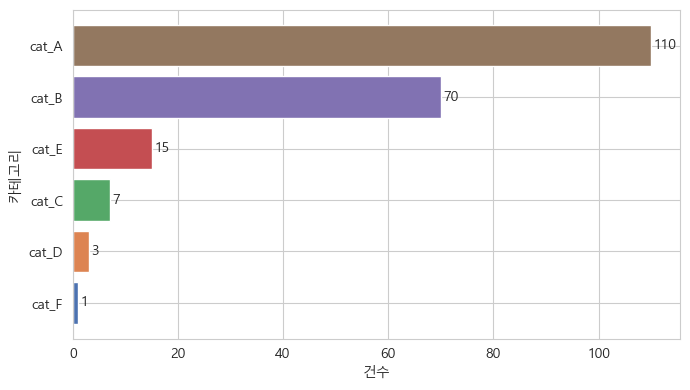

In [2]:
category_counts = {
    'cat_A': 110,
    'cat_B': 70,
    'cat_C': 7,
    'cat_D': 3,
    'cat_E': 15,
    'cat_F': 1
}

colors = [
    '#4C72B0',  # muted blue
    '#DD8452',  # muted orange
    '#55A868',  # muted green
    '#C44E52',  # muted red
    '#8172B2',  # muted purple
    '#937860'   # muted brown
]

df = pd.DataFrame(
    category_counts.items(),
    columns=['category', 'count']
).sort_values('count')

plt.figure(figsize=(7, 4))

bars = plt.barh(df['category'], df['count'], color=colors)

for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center'
    )

plt.xlabel('건수')
plt.ylabel('카테고리')
plt.tight_layout()
plt.show()

## 2. 비용–효과 사분면 모델 생성 후 액션 좌표 생성

- 도출된 개선 요구 항목의 실행 가능성을 평가하기 위해 **비용 – 효과** 기반 **사분면 모델**을 적용함. 
- 카테고리 분석 결과를 기반으로 실행 가능한 개선 과제 중 **10개 핵심 액션 항목**을 선정함.
- 각 항목에 대해 아래 내용 수행 후, **사분면 내 위치를 시각화**함.
    - 비용 점수 부여
    - 효과 점수 부여
    - 비용–효과 좌표 매핑

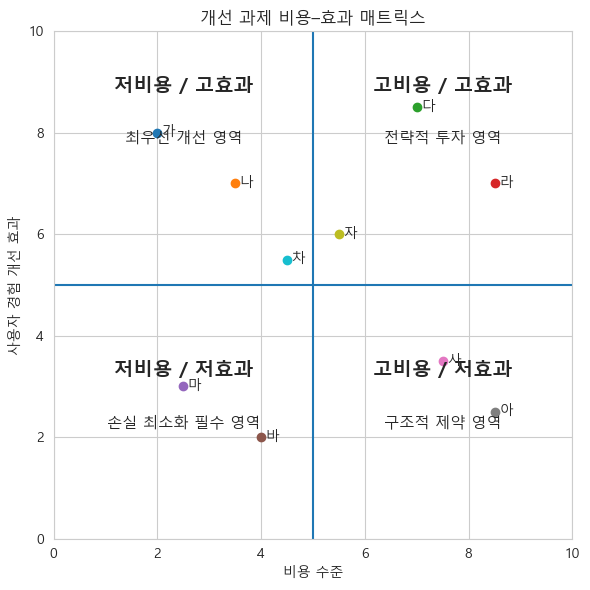

In [5]:
# 매트릭스 생성 
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.axvline(5)
ax.axhline(5)

ax.set_xlabel("비용 수준")
ax.set_ylabel("사용자 경험 개선 효과")

ax.set_title("개선 과제 비용–효과 매트릭스")

# 사분면 텍스트 
title_y_top = 8.8
subtitle_y_top = 7.8

title_y_bottom = 3.2
subtitle_y_bottom = 2.2

# 좌상단
ax.text(2.5, title_y_top, "저비용 / 고효과",
        ha='center', fontsize=14, fontweight='bold')

ax.text(2.5, subtitle_y_top, "최우선 개선 영역",
        ha='center', fontsize=11)

# 우상단
ax.text(7.5, title_y_top, "고비용 / 고효과",
        ha='center', fontsize=14, fontweight='bold')

ax.text(7.5, subtitle_y_top, "전략적 투자 영역",
        ha='center', fontsize=11)

# 좌하단
ax.text(2.5, title_y_bottom, "저비용 / 저효과",
        ha='center', fontsize=14, fontweight='bold')

ax.text(2.5, subtitle_y_bottom, "손실 최소화 필수 영역",
        ha='center', fontsize=11)

# 우하단
ax.text(7.5, title_y_bottom, "고비용 / 저효과",
        ha='center', fontsize=14, fontweight='bold')

ax.text(7.5, subtitle_y_bottom, "구조적 제약 영역",
        ha='center', fontsize=11)

# 액션 좌표
actions = {
    '가': (2, 8),
    '나': (3.5, 7),
    '다': (7, 8.5),
    '라': (8.5, 7),
    '마': (2.5, 3),
    '바': (4, 2),
    '사': (7.5, 3.5),
    '아': (8.5, 2.5),
    '자': (5.5, 6),
    '차': (4.5, 5.5)
}

for label, (x, y) in actions.items():
    ax.scatter(x, y)
    ax.text(x, y, f' {label}', va='center')

plt.tight_layout()
plt.show()

## 3. 각 액션별 우선순위 분류

| 구분            | 정의                    | 실행 해석             |
| ------------- | --------------------- | ----------------- |
| **저비용 / 고효과** | 최우선 실행 영역 | 가장 먼저 실행해야 함   |
| **저비용 / 저효과** | 필수 관리 영역   | 우선순위는 낮지만 지속 관리가 필요한 필수 영역  |
| **고비용 / 고효과** | 전략적 투자 검토 영역   | 개선 효과는 크지만 실행 부담 존재     |
| **고비용 / 저효과** | 구조적 제약 영역       | 실행 보류 또는 대안 검토 필요 |
